In [1]:
from google.colab import files

uploaded = files.upload()

Saving 01 Retail Inventory.xlsx to 01 Retail Inventory.xlsx


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [5]:
df = pd.read_excel('01 Retail Inventory.xlsx')

df.head()

,Product ID,Product Name,Category,Supplier Name,Unit Cost,Retail Price,Opening Stock,Units Sold,Closing Stock,Reorder Point,Stock Status
0,PRD-1001,Wine Glasses,Home & Kitchen,Heritage Brands,23.78,38.89,135,118,17,30,Low Stock
1,PRD-1002,Eye Mask,Beauty,Coastal Trading,15.67,24.53,86,10,76,9,In Stock
2,PRD-1003,Resistance Band,Sports & Outdoors,National Supply Group,5.59,11.88,319,195,124,47,In Stock
3,PRD-1004,Action Figure,Toys & Games,Pacific Wholesale,9.72,18.01,173,140,33,39,Low Stock
4,PRD-1005,Serving Tray,Home & Kitchen,Coastal Trading,8.22,13.90,32,8,24,7,In Stock


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product ID     1000 non-null   object 
 1   Product Name   1000 non-null   object 
 2   Category       1000 non-null   object 
 3   Supplier Name  1000 non-null   object 
 4   Unit Cost      1000 non-null   float64
 5   Retail Price   1000 non-null   float64
 6   Opening Stock  1000 non-null   int64  
 7   Units Sold     1000 non-null   int64  
 8   Closing Stock  1000 non-null   int64  
 9   Reorder Point  1000 non-null   int64  
 10  Stock Status   1000 non-null   object 
dtypes: float64(2), int64(4), object(5)
memory usage: 86.1+ KB


In [7]:
df.shape

(1000, 11)

In [8]:
df.columns

Index(['Product ID', 'Product Name', 'Category', 'Supplier Name', 'Unit Cost',
       'Retail Price', 'Opening Stock', 'Units Sold', 'Closing Stock',
       'Reorder Point', 'Stock Status'],
      dtype='object')

In [9]:
df.describe()

,Unit Cost,Retail Price,Opening Stock,Units Sold,Closing Stock,Reorder Point
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,16.061210,27.976780,262.451000,137.040000,125.411000,44.98300
std,14.172094,24.915064,140.104457,103.623232,99.023521,27.54468
min,0.520000,1.070000,20.000000,3.000000,4.000000,2.00000
25%,7.035000,11.962500,141.750000,53.000000,44.000000,22.00000
50%,12.430000,21.760000,261.000000,108.500000,96.000000,41.00000
75%,20.775000,35.307500,388.000000,204.000000,190.000000,64.25000
max,78.790000,157.400000,499.000000,463.000000,432.000000,119.00000


In [10]:
df.isnull().sum()

,0
Product ID,0
Product Name,0
Category,0
Supplier Name,0
Unit Cost,0
Retail Price,0
Opening Stock,0
Units Sold,0
Closing Stock,0
Reorder Point,0


In [11]:
df.fillna(0, inplace=True)

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.drop_duplicates(inplace=True)

In [15]:
df['Closing Stock'] < 0

,Closing Stock
0,False
1,False
2,False
3,False
4,False
...,...
995,False
996,False
997,False
998,False


In [16]:
df = df[df['Closing Stock'] >= 0]

In [17]:
df.groupby('Category')['Units Sold'].sum()

,Units Sold
Category,
Beauty,18137
Clothing,13736
Electronics,17621
Grocery,15364
Home & Kitchen,18387
Office Supplies,17112
Sports & Outdoors,16979
Toys & Games,19704


In [18]:
df.nlargest(10,'Units Sold')

,Product ID,Product Name,Category,Supplier Name,Unit Cost,Retail Price,Opening Stock,Units Sold,Closing Stock,Reorder Point,Stock Status
721,PRD-1722,Water Bottle,Sports & Outdoors,Summit Wholesale Inc,1.38,2.68,489,463,26,95,Low Stock
476,PRD-1477,Canned Soup,Grocery,Global Source Direct,8.12,15.92,490,456,34,56,Low Stock
791,PRD-1792,Coffee Mug Set,Home & Kitchen,Coastal Trading,12.36,17.50,471,435,36,93,Low Stock
673,PRD-1674,LED Desk Lamp,Electronics,Metro Distributors,65.20,131.63,497,432,65,76,Low Stock
810,PRD-1811,Coloring Set,Toys & Games,Pacific Wholesale,17.03,31.50,457,428,29,55,Low Stock
243,PRD-1244,Notebook A5,Office Supplies,AllGoods Supply Co,2.65,5.11,464,423,41,58,Low Stock
550,PRD-1551,Whistle,Sports & Outdoors,Premier Merchandise,11.41,15.84,478,422,56,62,Low Stock
970,PRD-1971,Baseball Cap,Clothing,AllGoods Supply Co,11.13,24.20,475,422,53,87,Low Stock
931,PRD-1932,Rice Crackers,Grocery,AllGoods Supply Co,10.45,14.70,448,417,31,102,Low Stock
469,PRD-1470,Building Blocks,Toys & Games,Heritage Brands,19.26,36.10,494,416,78,99,Low Stock


In [20]:
df.nsmallest(10,'Closing Stock')

,Product ID,Product Name,Category,Supplier Name,Unit Cost,Retail Price,Opening Stock,Units Sold,Closing Stock,Reorder Point,Stock Status
45,PRD-1046,Basic T-Shirt,Clothing,United Imports,24.64,41.77,42,38,4,5,Low Stock
385,PRD-1386,Coloring Set,Toys & Games,Premier Merchandise,7.70,11.57,61,57,4,14,Low Stock
654,PRD-1655,Storage Container,Home & Kitchen,National Supply Group,23.10,35.70,41,37,4,4,Low Stock
819,PRD-1820,Notebook A5,Office Supplies,Coastal Trading,7.80,13.91,25,21,4,2,In Stock
391,PRD-1392,Eye Mask,Beauty,Pacific Wholesale,11.30,17.07,76,71,5,7,Low Stock
425,PRD-1426,Nail File Set,Beauty,AllGoods Supply Co,16.02,32.05,88,83,5,11,Low Stock
703,PRD-1704,Coffee Mug Set,Home & Kitchen,AllGoods Supply Co,26.38,49.78,33,28,5,8,Low Stock
61,PRD-1062,Canned Soup,Grocery,United Imports,8.08,14.43,62,56,6,9,Low Stock
698,PRD-1699,Whistle,Sports & Outdoors,Global Source Direct,8.74,18.95,21,15,6,3,In Stock
709,PRD-1710,Dry Shampoo,Beauty,Summit Wholesale Inc,8.93,16.55,35,29,6,3,In Stock


In [22]:
df['Supplier Name'].value_counts()

,count
Supplier Name,
Premier Merchandise,119
National Supply Group,116
Heritage Brands,109
Coastal Trading,103
Global Source Direct,103
United Imports,99
Pacific Wholesale,98
Summit Wholesale Inc,92
Metro Distributors,89


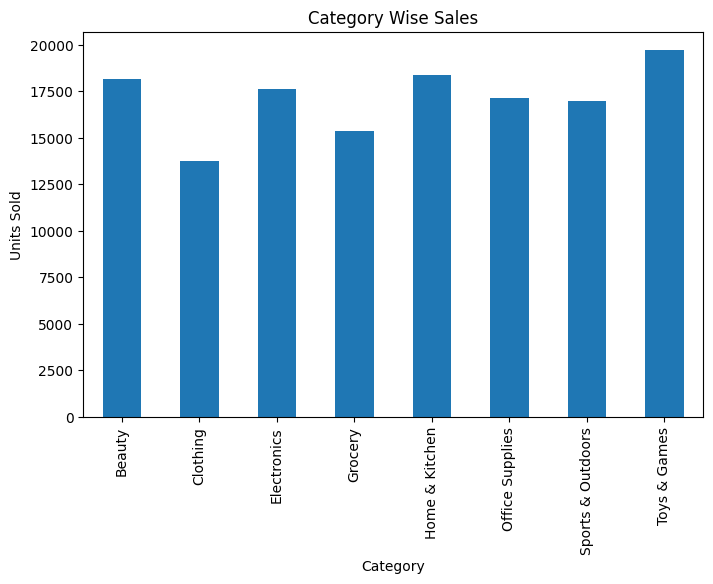

In [23]:
category_sales = df.groupby('Category')['Units Sold'].sum()

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')
plt.title('Category Wise Sales')
plt.xlabel('Category')
plt.ylabel('Units Sold')
plt.show()

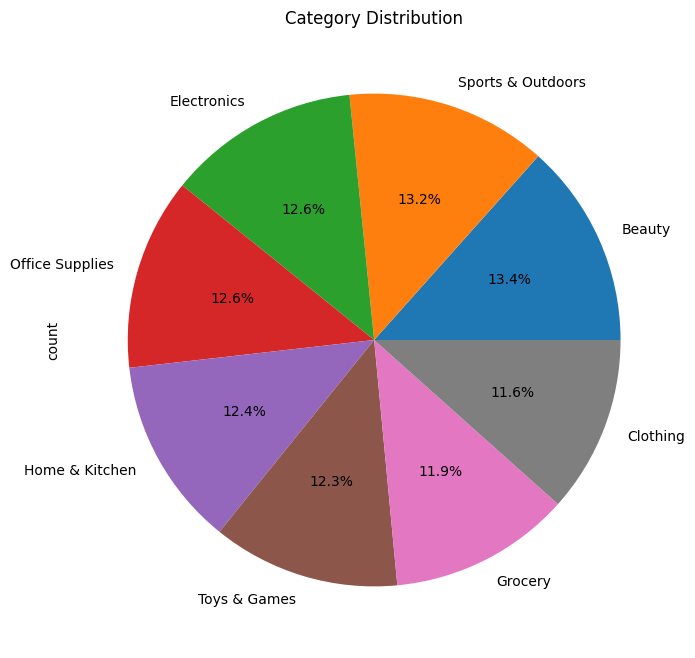

In [24]:
df['Category'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(8,8)
)

plt.title('Category Distribution')
plt.show()

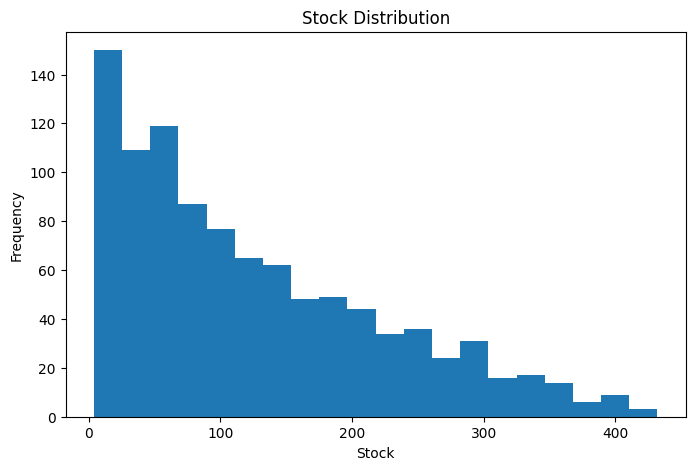

In [26]:
plt.figure(figsize=(8,5))
plt.hist(df['Closing Stock'], bins=20)

plt.title('Stock Distribution')
plt.xlabel('Stock')
plt.ylabel('Frequency')

plt.show()

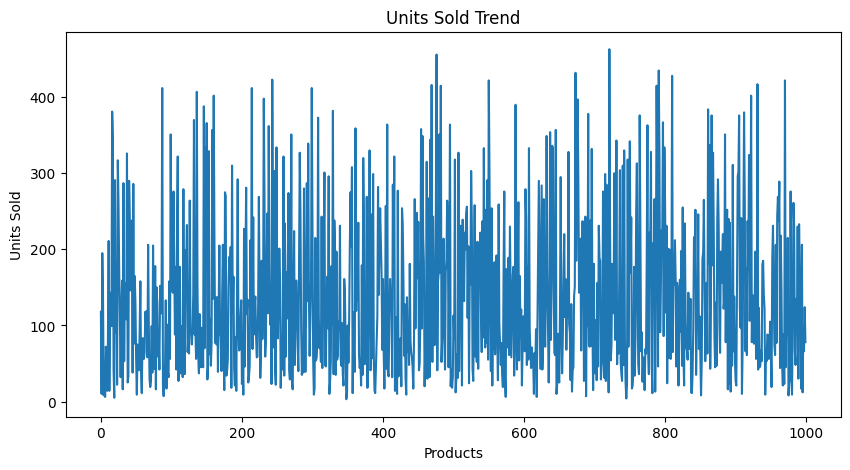

In [27]:
plt.figure(figsize=(10,5))

plt.plot(df['Units Sold'])

plt.title('Units Sold Trend')
plt.xlabel('Products')
plt.ylabel('Units Sold')

plt.show()

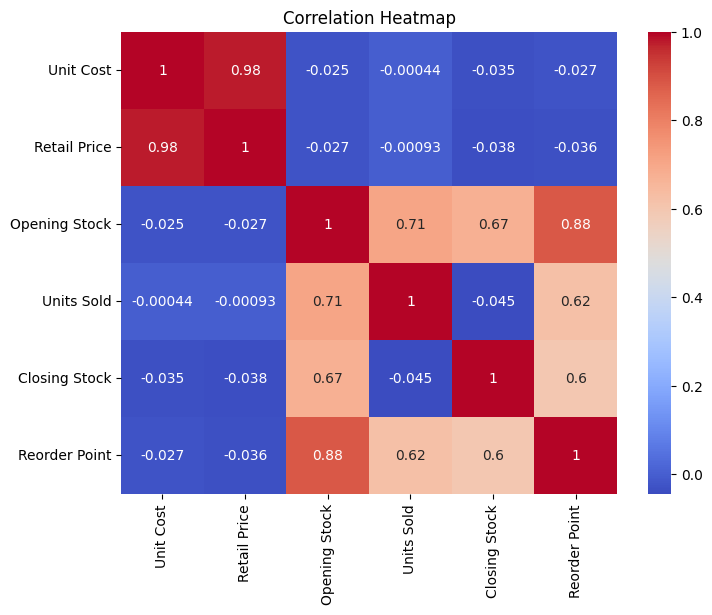

In [28]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()